In [170]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

1. Написать python код и рассказывать за какой этап решения навигационной задачи он отвечает. x, y - заданная траектория в исходном файле, эту траекторию нужно отрисовать. 
2. Сходимость МНК (1 точка) 
3. Сравнение исходной траектории ( x, y ) и полученной траектории. На одном графике. 
Сравнивать по СКО для каждой точки. 
4. Выводы

**Шум для каждой дальности 0.5м**

### Парсинг измеренных расстояний и определение координат маяков

In [171]:
# Чтение данных из файла
data = pd.read_csv('trajectory_v2.txt', sep='\s+')
data = data.iloc[:-1] # Удаление последней строчки (с 'end')

# Создание матрицы измерений дальностей
# Каждая строка - это 4 измерения дальностей для соответствующего момента времени
R_measured = data[['r1', 'r2', 'r3', 'r4']].values

print("Матрица измерений дальностей R_measured:")
print("Размерность:", R_measured.shape)
print("\nПервые 5 строк:")
print(R_measured[:5])
# print("\nПоследние 5 строк:")
# print(R_measured[-5:])
print("--------------------------------------------")

beacons = np.array([[1e-10, 1e-10], [0, 6], [6, 6], [6, 0]]) # координаты маяков

# 4 отдельных вектора-столбца для каждого маяка
r1 = R_measured[:, 0]  # измерения до первого маяка [0, 0]
r2 = R_measured[:, 1]  # измерения до второго маяка [0, 6] 
r3 = R_measured[:, 2]  # измерения до третьего маяка [6, 6]
r4 = R_measured[:, 3]  # измерения до четвертого маяка [6, 0]

print("Координаты маяков:")
for i, beacon in enumerate(beacons):
    print(f"Маяк {i+1}: {beacon}")

print("Первые 5 измерений для каждого маяка:")
print("Маяк 1 (r1):", r1[:5])
print("Маяк 2 (r2):", r2[:5])
print("Маяк 3 (r3):", r3[:5])
print("Маяк 4 (r4):", r4[:5])
print("--------------------------------------------")

# Истинные координаты для сравнения
stamp = data['stamp'].values
x_true = data['x_cord'].values
y_true = data['y_cord'].values

print("Шаг (stamp):", stamp[:5])
print("Истинная координата x (x_true):", x_true[50:60])
print("Истинная координата y (y_true):", y_true[50:60])


Матрица измерений дальностей R_measured:
Размерность: (152, 4)

Первые 5 строк:
[[ 1.294  6.967 10.394  7.398]
 [ 1.05   7.351  9.941  6.923]
 [ 1.465  6.546  9.27   6.562]
 [ 1.289  7.243  9.254  6.896]
 [ 1.132  6.38   9.194  6.419]]
--------------------------------------------
Координаты маяков:
Маяк 1: [1.e-10 1.e-10]
Маяк 2: [0. 6.]
Маяк 3: [6. 6.]
Маяк 4: [6. 0.]
Первые 5 измерений для каждого маяка:
Маяк 1 (r1): [1.294 1.05  1.465 1.289 1.132]
Маяк 2 (r2): [6.967 7.351 6.546 7.243 6.38 ]
Маяк 3 (r3): [10.394  9.941  9.27   9.254  9.194]
Маяк 4 (r4): [7.398 6.923 6.562 6.896 6.419]
--------------------------------------------
Шаг (stamp): ['0' '1' '2' '3' '4']
Истинная координата x (x_true): [2.5  2.5  2.57 2.64 2.71 2.78 2.85 2.92 2.99 3.06]
Истинная координата y (y_true): [2.5  2.5  2.43 2.36 2.29 2.22 2.15 2.08 2.01 1.94]


### Отрисовка изначально заданной траектории

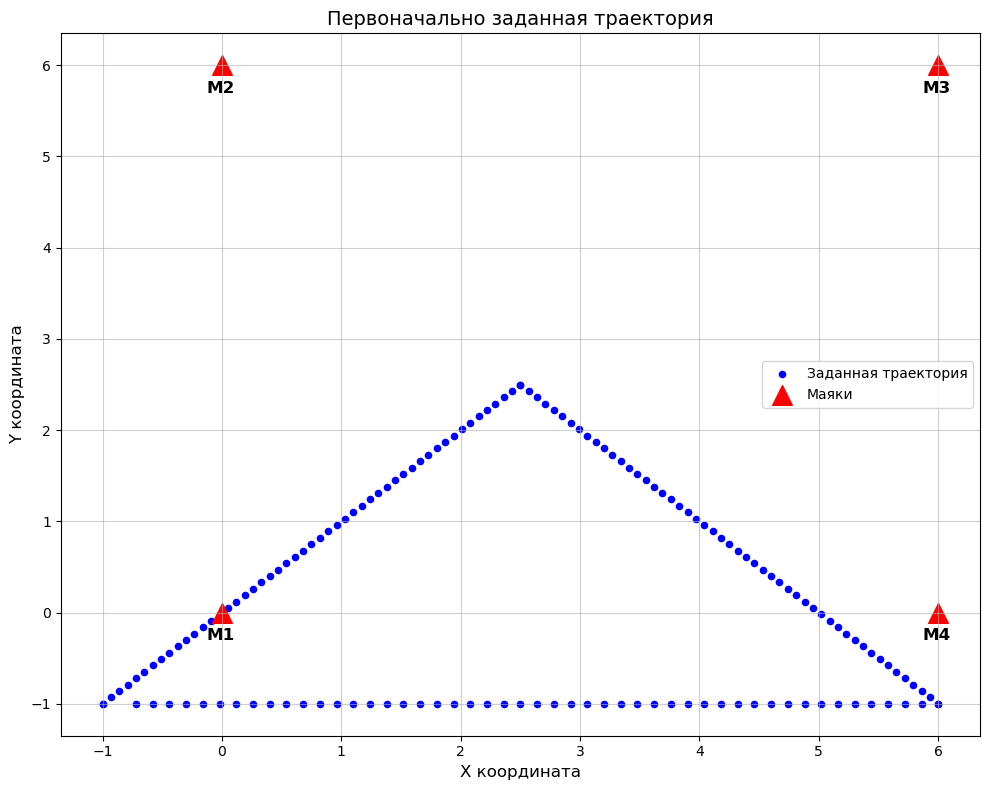

Начальная точка: (-1.00, -1.00)
Конечная точка: (-1.00, -1.00)
Общая длина траектории: 16.90 м


In [172]:
# Отрисовка первоначальной траектории
plt.figure(figsize=(10, 8))
plt.scatter(x_true, y_true, c='blue', s=20, alpha=1, label='Заданная траектория')

# Отмечаем маяки на графике
plt.scatter(beacons[:, 0], beacons[:, 1], c='red', s=200, marker='^', label='Маяки')

# Добавление подписи маякам на графике
for i, beacon in enumerate(beacons): 
    plt.text(beacon[0] - 0.13, beacon[1] - 0.3, f'M{i+1}', fontsize=12, fontweight='bold')

# Настройки графика
plt.xlabel('X координата', fontsize=12)
plt.ylabel('Y координата', fontsize=12)
plt.title('Первоначально заданная траектория', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.6)

plt.tight_layout()
plt.show()

distance = np.sum(np.sqrt(np.diff(x_true)**2 + np.diff(y_true)**2))

print(f"Начальная точка: ({x_true[0]:.2f}, {y_true[0]:.2f})")
print(f"Конечная точка: ({x_true[-1]:.2f}, {y_true[-1]:.2f})")
print(f"Общая длина траектории: {distance:.2f} м")

# x_diff = [x1-x0, x2-x1, x3-x2, ..., x_n - x_{n-1}]
# y_diff = [y1-y0, y2-y1, y3-y2, ..., y_n - y_{n-1}]
# distances_squared = [dx₁² + dy₁², dx₂² + dy₂², dx₃² + dy₃², ...]
# segment_lengths = [√(dx₁² + dy₁²), √(dx₂² + dy₂²), √(dx₃² + dy₃²), ...]
# total_length = segment_length₁ + segment_length₂ + segment_length₃ + ...

### Инициализация матриц

In [173]:
#Для каждого момента времени имеем вектор измерений:
R_matrix_measured = np.column_stack([r1, r2, r3, r4])
# print("\nОбъединенная матрица измеренных R:")
# print(R_matrix_measured)
# print(f"Размерность матрицы: {R_matrix_measured.shape}")

# Координаты объекта (начальное приближение)
object_coords = np.array([0, 0])  # x0, y0

# Создаем матрицу R

R = np.zeros(4)  # вектор-строка (4,)
for i in range(4):
    distance = np.sqrt((beacons[i, 0] - object_coords[0])**2 + 
                       (beacons[i, 1] - object_coords[1])**2)
    R[i] = distance

print("Матрица R (расстояния от объекта до маяков):")
print(R)
print(f"Размерность: {R.shape}")

# Создаем матрицу H_divisible размером 4×2
H_divisible = np.zeros((4, 2))

# Заполняем матрицу H_divisible
for i in range(4):
    H_divisible[i, 0] = -(beacons[i, 0] - object_coords[0]) 
    H_divisible[i, 1] = -(beacons[i, 1] - object_coords[1])

H_divisible = H_divisible.T

print("Матрица H_divisible:")
print(H_divisible)
print(f"Размерность: {H_divisible.shape}")  

H = (H_divisible / R)

H = H.T

print("Матрица H:")
print(H)
print(f"Размерность: {H.shape}") 

Матрица R (расстояния от объекта до маяков):
[1.41421356e-10 6.00000000e+00 8.48528137e+00 6.00000000e+00]
Размерность: (4,)
Матрица H_divisible:
[[-1.e-10 -0.e+00 -6.e+00 -6.e+00]
 [-1.e-10 -6.e+00 -6.e+00 -0.e+00]]
Размерность: (2, 4)
Матрица H:
[[-0.70710678 -0.70710678]
 [-0.         -1.        ]
 [-0.70710678 -0.70710678]
 [-1.         -0.        ]]
Размерность: (4, 2)


### Реализация итерационного алгоритма

Средняя ошибка: 0.27517458774779296 м


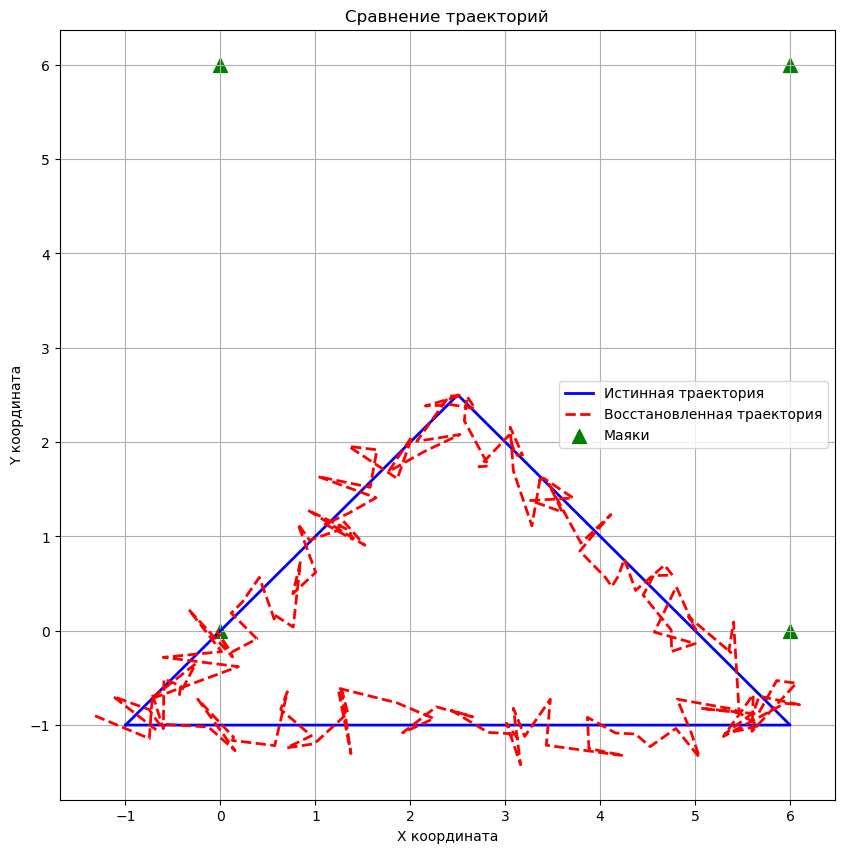

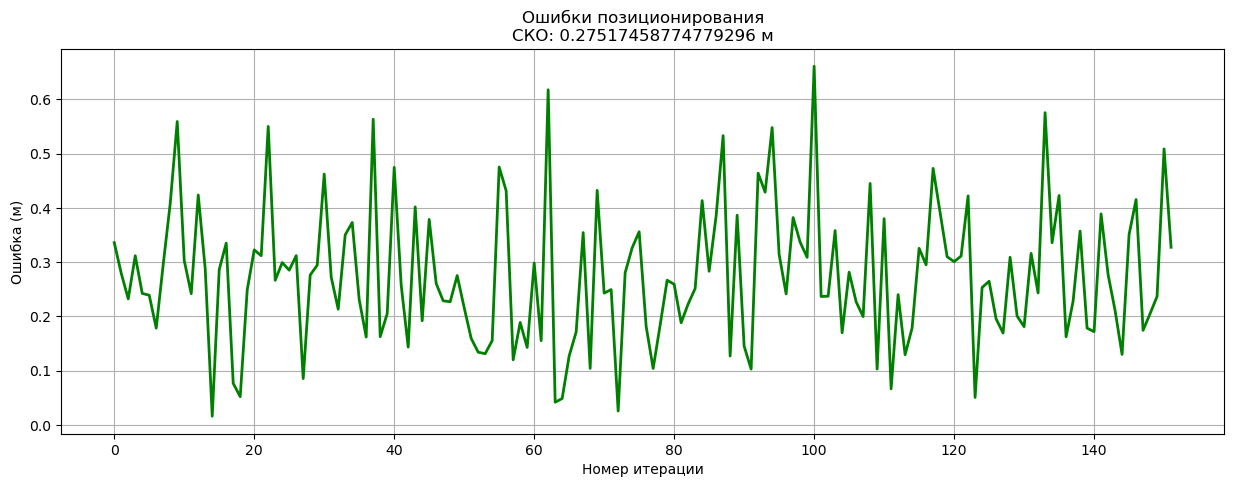

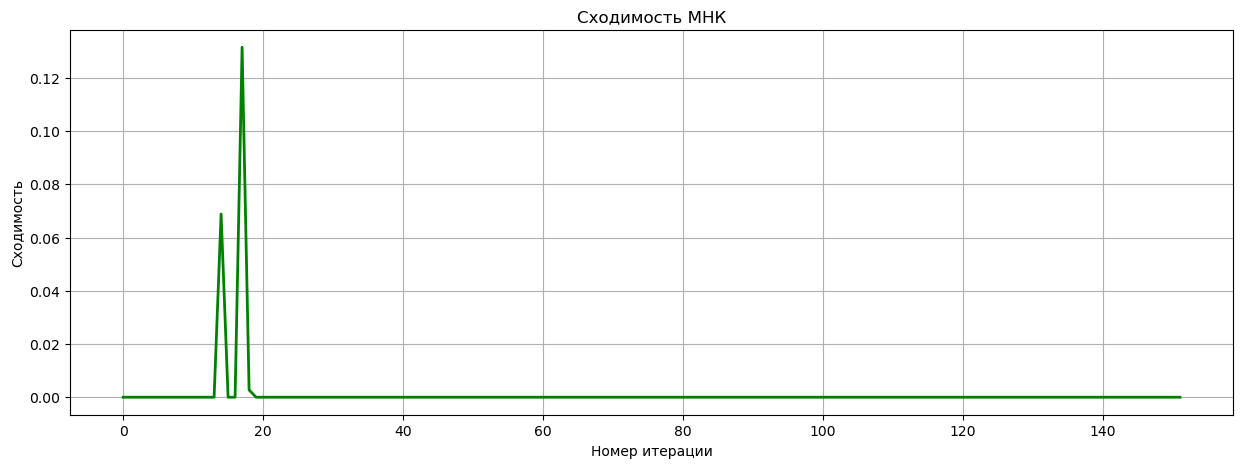

In [174]:
# Функция для решения навигационной задачи методом МНК
def solve_navigation(R_measured_point, beacons, initial_guess=np.array([0, 0]), tol=1e-6, max_iter=150):

    x_est = initial_guess.astype(float).copy()  # Явно указываем тип float
    for k in range(max_iter):
        # 1. Вычисляем f(x_{k-1}) - расчетные расстояния
        R = np.zeros(4)
        for i in range(4):
            R[i] = np.sqrt((beacons[i, 0] - x_est[0])**2 + (beacons[i, 1] - x_est[1])**2)

        # 2. Вычисляем матрицу H(x_{k-1})

        # Создаем матрицу H_divisible размером 4×2
        H_divisible = np.zeros((4, 2))

        # Заполняем матрицу H_divisible
        for i in range(4):
            H_divisible[i, 0] = -(beacons[i, 0] - x_est[0]) 
            H_divisible[i, 1] = -(beacons[i, 1] - x_est[1])

        H_divisible = H_divisible.T
        H = (H_divisible / R)
        H = H.T
 
        # 3. Вычисляем (H^T H)^{-1} H^T
        HT_H = H.T @ H
        try:
            HT_H_inv = np.linalg.inv(HT_H)
        except:
            HT_H_inv = np.linalg.pinv(HT_H) # псевдообратная матрица
        
        # 4. Вычисляем (H^T (R_measured - R))
        value = R_measured_point - R
        delta = HT_H_inv @ H.T @ value
        convergence = np.linalg.norm(delta) # сходимость
        
        # 5. Обновляем оценку
        x_prev = x_est.copy()
        x_est += delta

        
        # 6. Проверяем критерий останова
        if convergence < tol:
            break
        
    
    return x_est, convergence

# Решаем навигационную задачу для всех точек
x_estimated = []
y_estimated = []
convergance = []

for i in range(len(R_matrix_measured)):
    # Решаем для каждого срез измерений дальностей от маяков
    estimated_coords, conv = solve_navigation(R_matrix_measured[i], beacons)
    x_estimated.append(estimated_coords[0])
    y_estimated.append(estimated_coords[1])
    convergance.append(conv) # формируем массив сходимости

# Вычисляем ошибки
errors = np.sqrt((x_estimated - x_true)**2 + (y_estimated - y_true)**2)
SKO    = np.mean(errors)

print(f"Средняя ошибка: {SKO} м")

# Визуализация результатов
iterations = np.arange(0, len(stamp), 20)
# 1. Сравнение траекторий
plt.figure(figsize=(10, 10))
plt.plot(x_true, y_true, 'b-', label='Истинная траектория', linewidth=2)
plt.plot(x_estimated, y_estimated, 'r--', label='Восстановленная траектория', linewidth=2)
plt.scatter(beacons[:, 0], beacons[:, 1], c='green', s=100, marker='^', label='Маяки')
plt.xlabel('X координата')
plt.ylabel('Y координата')
plt.title('Сравнение траекторий')
plt.legend()
plt.grid(True)
plt.show()

# 2. Ошибки позиционирования
plt.figure(figsize=(15, 5))
plt.plot(stamp, errors, 'g-', linewidth=2)
plt.xlabel('Номер итерации')
plt.xticks(iterations)  # подписываем ось X номерами итераций
plt.ylabel('Ошибка (м)')
plt.title(f'Ошибки позиционирования\nСКО: {SKO} м')
plt.grid(True)
plt.show()

# 3. Сходимость для первой точки
plt.figure(figsize=(15, 5))
# Покажем пример сходимости для демонстрации
plt.plot(stamp, convergance, 'g-', linewidth=2)
plt.xlabel('Номер итерации')
plt.xticks(iterations)  # подписываем ось X номерами итераций
plt.ylabel('Сходимость')
plt.title('Сходимость МНК')
plt.grid(True)
plt.show()
